# SAFFRON demo: Novae embeddings on the colorectal tumor-stroma boundary

This notebook walks through the two components of SAFFRON on real data:

1. Train a Matryoshka sparse autoencoder (SAE) on SFM embeddings `Z` to learn sparse, interpretable features `H`.
2. Evaluate `H` against a known measure of spatial variation `τ` — correlate every feature with `τ`, then use orthogonal matching pursuit (OMP) to find a minimal reconstructing subset.

`Z` is the train-from-scratch Novae embedding (64-dim) for the colorectal tumor Visium dataset, and `τ` is the GASTON isodepth — a 1-D tumor-core-to-stroma axis. The SAE is trained on the full tissue, but we evaluate and visualize it restricted to the two-domain boundary region (the tumor domain plus its adjacent stroma domain). Both `Z` and `τ` are bundled in `data/colorectal_novae_demo.npz` as small precomputed arrays (no raw counts, no model weights).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from saffron import SAFFRON
from saffron.utils import topo_map, rotate_by_theta

## Load Z and τ, restrict to the tumor + adjacent-stroma boundary region

In [2]:
data = np.load("data/colorectal_novae_demo.npz")
Z = data["Z"]                         # (3900, 64) Novae train-from-scratch embedding, full tissue
τ_full = data["isodepth"]             # (3900,) GASTON isodepth: tumor-core-to-stroma axis
domain_labels = data["domain_labels"]
S_scaled = data["S_scaled"]

tumor_domain = int(domain_labels.max())
region_mask = (domain_labels == tumor_domain) | (domain_labels == tumor_domain - 1)  # tumor + adjacent stroma

S_rot = rotate_by_theta(S_scaled, np.radians(-90))
S_rot_r = S_rot[region_mask]
sx, sy = S_rot_r[:, 0], S_rot_r[:, 1]
τ = τ_full[region_mask]

print(f"Z: {Z.shape} (full tissue)   tumor + adjacent-stroma spots: {region_mask.sum()}")

Z: (3900, 64) (full tissue)   tumor + adjacent-stroma spots: 2054


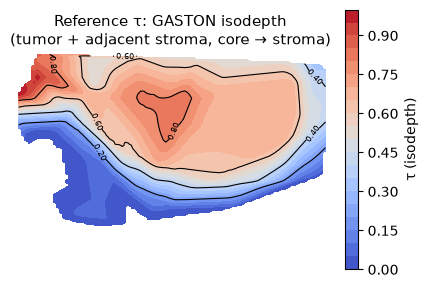

In [3]:
fig, ax = plt.subplots(figsize=(5, 4.5))
topo_map(ax, sx, sy, τ, fig=fig, cmap="coolwarm", colorbar_label="τ (isodepth)")
ax.set_title("Reference τ: GASTON isodepth\n(tumor + adjacent stroma, core → stroma)", fontsize=11)
plt.show()

## Step 1: the Matryoshka SAE

Rather than retraining from scratch, we load the actual SAE features (`H`, shape `(3900, 256)`) produced by training on this train-from-scratch Novae embedding — the same result reported in the paper for this dataset — so the feature numbers below match the paper exactly. It was produced by `saffron.train_sae(Z, latent_dim=256, k=16, matryoshka_dims=[64, 128, 256], sparsity_mode="batchtopk")`, the default configuration for 64-dim embeddings; if the cached file isn't present, we fall back to training it fresh with that same call.

In [4]:
import os

cache_path = "data/colorectal_novae_train_sae.npz"
model = SAFFRON(latent_dim=256, k=16, matryoshka_dims=[64, 128, 256], epochs=100)

if os.path.exists(cache_path):
    H = np.load(cache_path)["H"]
    print(f"Loaded the paper's precomputed SAE features from {cache_path}")
else:
    model.fit(Z)
    H = model.sae_result_.Z
    np.savez_compressed(cache_path, H=H)
    print(f"Trained SAE and cached features to {cache_path}")

Loaded the paper's precomputed SAE features from data/colorectal_novae_train_sae.npz


## Step 2: evaluate against τ, restricted to the boundary region

`model.evaluate(τ, H=H_region)` scans every SAE feature's Spearman correlation with `τ` (restricted to each feature's own active support) and, since the best correlation clears the default threshold, automatically runs OMP to find a minimal reconstructing subset — all computed using only the tumor + adjacent-stroma spots.

In [5]:
H_region = H[region_mask]        # (n_region, 256) restricted to the boundary region

result = model.evaluate(τ, H=H_region)
corr = result.correlation
print(f"Best feature: #{corr.best_feature}   rho = {corr.best_rho:+.3f}   "
      f"(support: {corr.support_size[corr.best_feature]} spots)")

Best feature: #10   rho = -0.883   (support: 553 spots)


Notice that the single highest-|ρ| feature can be one active on only a handful of spots — with so few active cells, a sparse feature can reach a high correlation by chance. Looking at the top 10 by |ρ| alongside their support size makes this visible directly, and lets us pick a feature with both high correlation *and* enough support to be a meaningful spatial pattern for the comparison below.

In [6]:
top_idx = np.argsort(np.abs(corr.rho))[::-1][:10]
print("Top 10 SAE features by |rho|:")
for idx in top_idx:
    print(f"  feature #{idx:3d}   rho = {corr.rho[idx]:+.3f}   support = {corr.support_size[idx]:4d} spots")

feature_idx = next(idx for idx in top_idx if corr.support_size[idx] >= 100)
print(f"\nUsing feature #{feature_idx} for the spatial comparison below "
      f"(highest |rho| with support >= 100 spots).")

Top 10 SAE features by |rho|:
  feature # 10   rho = -0.883   support =  553 spots
  feature # 45   rho = +0.831   support =  651 spots
  feature # 59   rho = -0.820   support =  214 spots
  feature #112   rho = -0.798   support =   14 spots
  feature # 37   rho = -0.797   support =  449 spots
  feature #164   rho = -0.791   support =   16 spots
  feature # 27   rho = -0.791   support =   31 spots
  feature #  7   rho = -0.784   support =  294 spots
  feature # 96   rho = -0.782   support =   50 spots
  feature #177   rho = -0.764   support =   11 spots

Using feature #10 for the spatial comparison below (highest |rho| with support >= 100 spots).


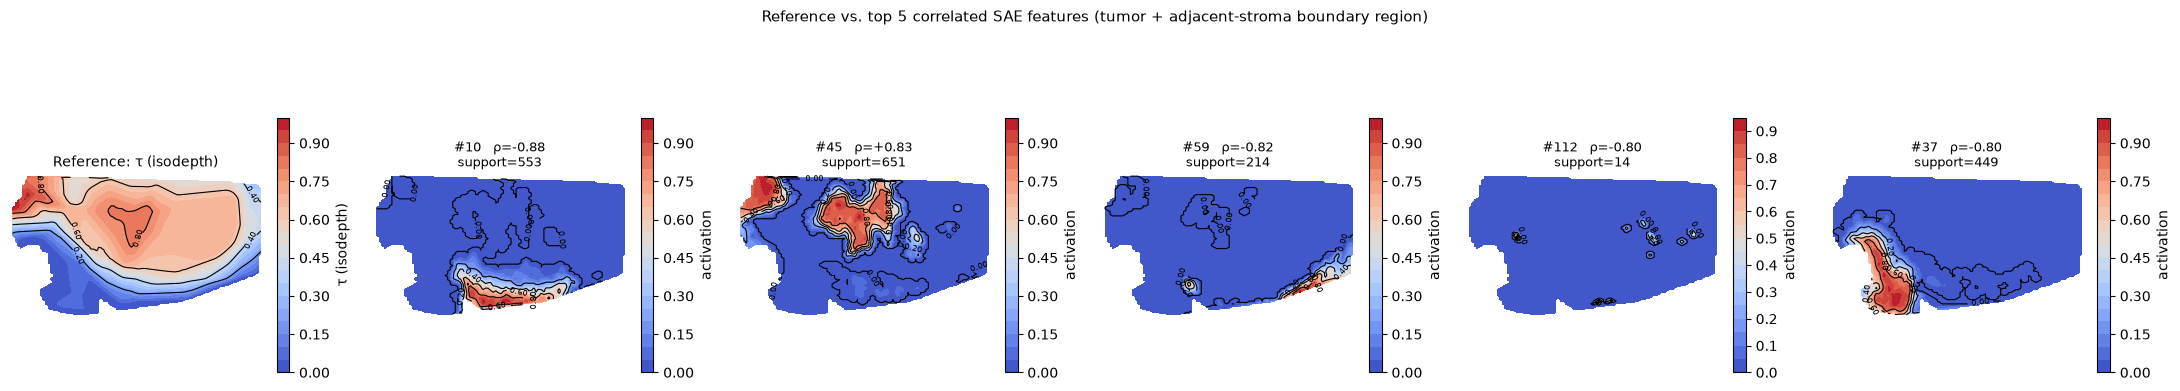

In [7]:
top5 = top_idx[:5]

fig, axes = plt.subplots(1, 6, figsize=(22, 4))
topo_map(axes[0], sx, sy, τ, fig=fig, cmap="coolwarm", colorbar_label="τ (isodepth)")
axes[0].set_title("Reference: τ (isodepth)", fontsize=10)

for ax, idx in zip(axes[1:], top5):
    topo_map(ax, sx, sy, H_region[:, idx], fig=fig, cmap="coolwarm", colorbar_label="activation")
    ax.set_title(f"#{idx}   ρ={corr.rho[idx]:+.2f}\nsupport={corr.support_size[idx]}", fontsize=9)

fig.suptitle("Reference vs. top 5 correlated SAE features (tumor + adjacent-stroma boundary region)",
             fontsize=11, y=1.05)
plt.tight_layout()
plt.show()

## Minimal reconstructing feature set (OMP), boundary region only

For datasets where the Spearman correlation is high, SAFFRON uses orthogonal matching pursuit to find a *minimal* set of SAE features that linearly reconstruct `τ`. Below, cross-validated R² as a function of the number of features shows how quickly reconstruction quality saturates, alongside a dense RidgeCV-on-all-features reference.

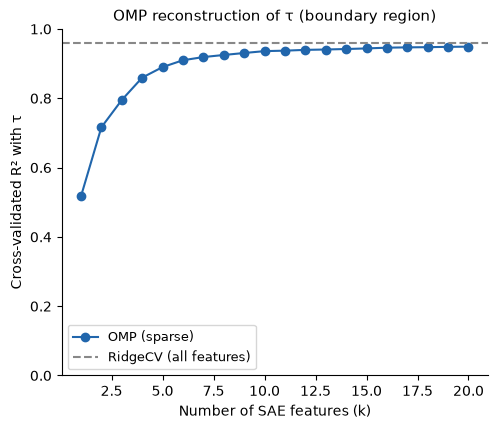

Selected features (in order added): [np.int64(6), np.int64(21), np.int64(41), np.int64(47), np.int64(79)]
Coefficients: [0.622 0.333 0.173 0.25  0.06 ]
R2 with 2 features: 0.716   |   R2 with all 256 features (RidgeCV): 0.960


In [8]:
curve = result.omp_curve
selection = result.omp_selection

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(curve.k_values, curve.r2, "o-", color="#2166AC", label="OMP (sparse)")
ax.axhline(curve.ridge_r2, color="#888888", ls="--", label="RidgeCV (all features)")
ax.set_xlabel("Number of SAE features (k)"); ax.set_ylabel("Cross-validated R\u00b2 with τ")
ax.set_ylim(0, 1); ax.legend(fontsize=9); ax.spines[["top", "right"]].set_visible(False)
ax.set_title("OMP reconstruction of τ (boundary region)", fontsize=11)
plt.show()

print(f"Selected features (in order added): {selection.selected_features[:5]}")
print(f"Coefficients: {np.round(selection.coefficients[:5], 3)}")
print(f"R2 with 2 features: {curve.r2[1]:.3f}   |   R2 with all {H.shape[1]} features (RidgeCV): {curve.ridge_r2:.3f}")

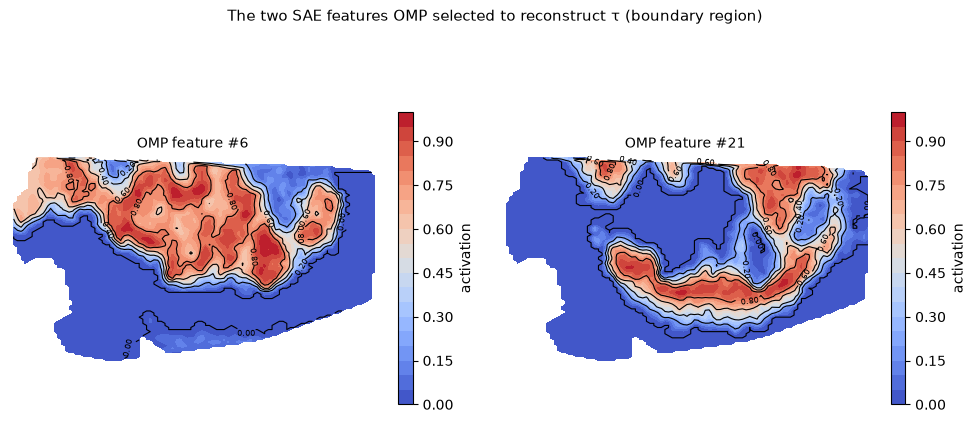

In [9]:
top2 = selection.selected_features[:2]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, feat in zip(axes, top2):
    topo_map(ax, sx, sy, H_region[:, feat], fig=fig, cmap="coolwarm", colorbar_label="activation")
    ax.set_title(f"OMP feature #{feat}", fontsize=10)
fig.suptitle("The two SAE features OMP selected to reconstruct τ (boundary region)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Using this on your own data

Swap `Z` for any embedding matrix (an SFM, a single-cell FM, or raw gene expression) and `τ` for any per-cell measure of spatial variation you already have computed (a different isodepth axis, a disease-signature score, distance to a pathological feature, ...). SAFFRON itself does not generate embeddings or spatial-variation measures, or restrict analyses to particular regions — see `README.md` for the library's scope; the boundary-region restriction above is a choice made in this notebook, not something SAFFRON imposes.